Successfully loaded: dataset/normalized/Node_A_train_normalized.csv
Successfully loaded: dataset/normalized/Node_B_train_normalized.csv
Successfully loaded: dataset/normalized/Node_C_train_normalized.csv
Successfully loaded: dataset/normalized/Node_D_train_normalized.csv
Successfully loaded: dataset/normalized/Node_E_train_normalized.csv
Successfully loaded: dataset/normalized/Node_F_train_normalized.csv
Successfully loaded: dataset/normalized/Node_G_train_normalized.csv
Successfully loaded: dataset/normalized/Node_H_train_normalized.csv
Combined Nodes Dataset Shape: (448000, 7)


/tmp/ipykernel_66535/3988646871.py:266: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_66535/3988646871.py:275: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)
/tmp/ipykernel_66535/3988646871.py:266: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_66535/3988646871.py:275: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)
/tmp/ipykernel_66535/3988646871.py:266: FutureWarning: 

Passing `pa

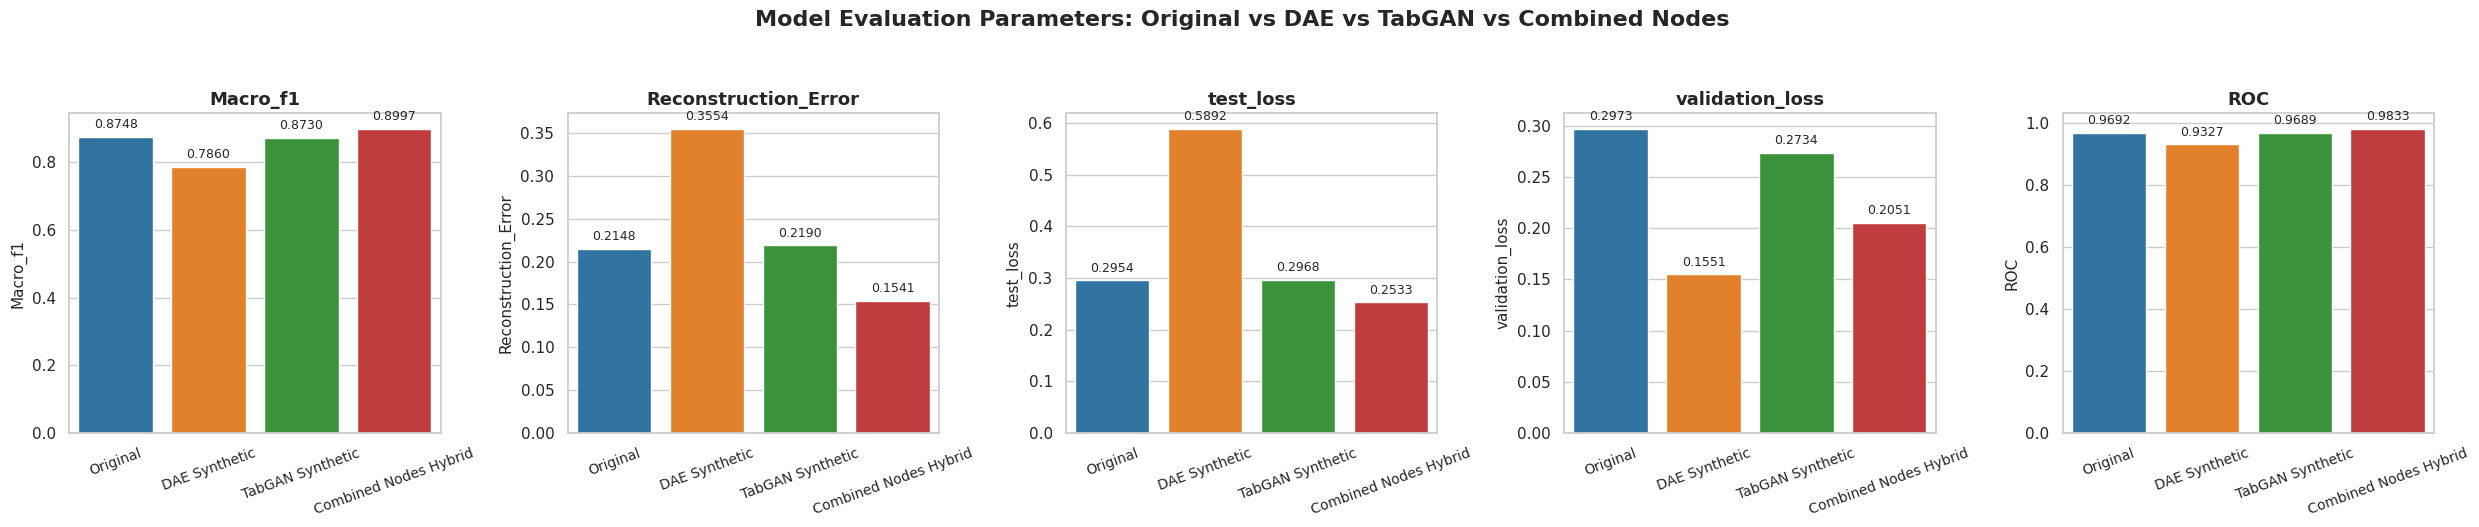

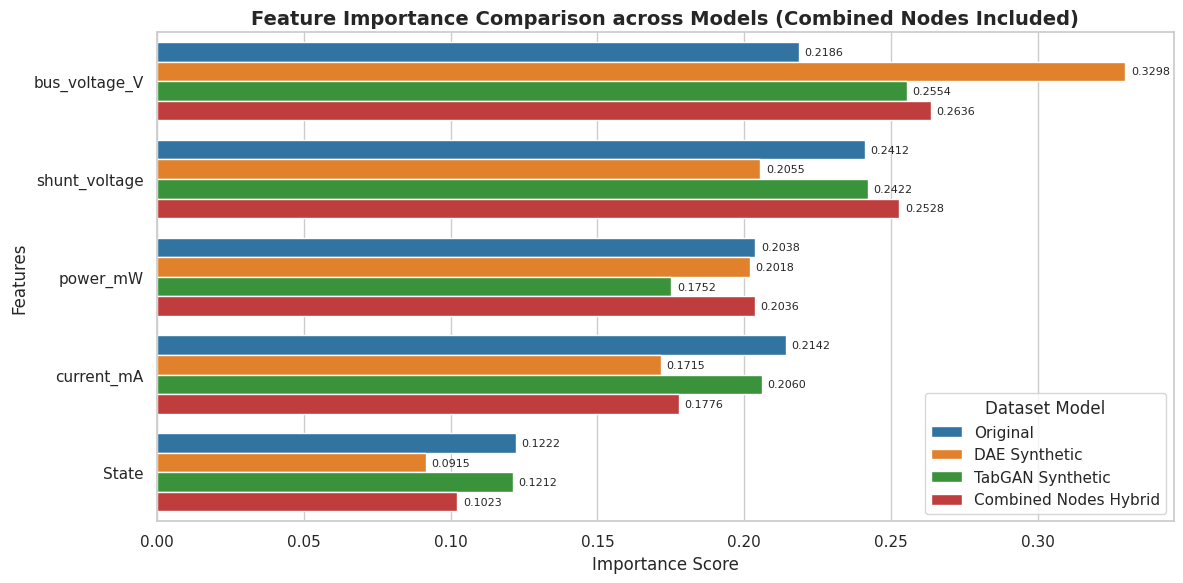

In [3]:
# Cell: Node Evaluation & Comparison with Original, DAE, and TabGAN
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# Create plots directory if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Set visual style
sns.set_theme(style="whitegrid")

# Define consistent color palette for the 4 datasets (Original, DAE, TabGAN, Combined Nodes)
palette_4 = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


def clean_dataset_label(name):
    if "Original" in name:
        return "Original"
    elif "DAE" in name:
        return "DAE Synthetic"
    elif "TabGAN" in name:
        return "TabGAN Synthetic"
    elif "Combined" in name or "Node" in name:
        return "Combined Nodes Hybrid"
    return name


def consolidate_feature_importances(imp_dict):
    consolidated = {}
    state_importance = 0.0

    for feat, val in imp_dict.items():
        if feat.startswith("State_"):
            state_importance += val
        else:
            consolidated[feat] = val

    consolidated["State"] = state_importance
    return consolidated


# ---------------------------------------------------------
# Load base datasets
# ---------------------------------------------------------
df_orig_train = pd.read_csv("../data/dataset_synthetic extension/hyperparameter_tuning/dataset/normalized/train_dataset_normalized.csv")
df_dae_train = pd.read_csv(
    "../data/dataset_synthetic extension/hyperparameter_tuning/dataset/normalized/dae_synthetic_dataset_normalized.csv"
)
df_tabgan_train = pd.read_csv(
    "../data/dataset_synthetic extension/hyperparameter_tuning/dataset/normalized/tabgan_synthetic_dataset_normalized.csv"
)
df_orig_test = pd.read_csv("../data/dataset_synthetic extension/hyperparameter_tuning/dataset/normalized/test_dataset_normalized.csv")

# ---------------------------------------------------------
# Load and Combine All Node Datasets
# ---------------------------------------------------------
# Add all your available node IDs to this list
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
df_node_list = []

for n_id in NODES:
    path = f"dataset/normalized/Node_{n_id}_train_normalized.csv"
    try:
        df = pd.read_csv(path)
        df_node_list.append(df)
        print(f"Successfully loaded: {path}")
    except FileNotFoundError:
        print(f"Warning: File not found -> {path}")

if not df_node_list:
    raise ValueError("No node datasets were found. Please check your file paths and 'node_ids' list.")

# Concatenate all node dataframes into one large dataset
df_node_train = pd.concat(df_node_list, ignore_index=True)
print(f"Combined Nodes Dataset Shape: {df_node_train.shape}")


target_col = "Attack"
features_to_keep = [
    "shunt_voltage",
    "bus_voltage_V",
    "current_mA",
    "power_mW",
    "State",
]


def preprocess_dataset(df, label_encoder=None, is_train=True):
    cols = [c for c in features_to_keep if c in df.columns] + [target_col]
    df_filtered = df[cols].copy()
    
    # Skip rows containing the unseen label 'noneX2'
    df_filtered = df_filtered[df_filtered[target_col] != 'noneX2'].copy()

    if "State" in df_filtered.columns:
        df_filtered = pd.get_dummies(df_filtered, columns=["State"], drop_first=False)

    for state_val in ["idle", "charging"]:
        col_name = f"State_{state_val}"
        if col_name not in df_filtered.columns:
            df_filtered[col_name] = 0

    if is_train:
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(df_filtered[target_col])
    else:
        y = label_encoder.transform(df_filtered[target_col])

    X = df_filtered.drop(columns=[target_col])
    return X, y, label_encoder


X_orig_train, y_orig_train, le = preprocess_dataset(
    df_orig_train, is_train=True
)
X_dae_train, y_dae_train, _ = preprocess_dataset(
    df_dae_train, label_encoder=le, is_train=False
)
X_tabgan_train, y_tabgan_train, _ = preprocess_dataset(
    df_tabgan_train, label_encoder=le, is_train=False
)
X_node_train, y_node_train, _ = preprocess_dataset(
    df_node_train, label_encoder=le, is_train=False
)
X_orig_test, y_orig_test, _ = preprocess_dataset(
    df_orig_test, label_encoder=le, is_train=False
)

feature_order = X_orig_train.columns.tolist()
X_dae_train = X_dae_train[feature_order]
X_tabgan_train = X_tabgan_train[feature_order]
X_node_train = X_node_train[feature_order]
X_orig_test = X_orig_test[feature_order]


def evaluate_model(model, X_train, y_train, X_test, y_test, dataset_name):
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)

    macro_f1 = f1_score(y_test, y_test_pred, average="macro")
    reconstruction_error = mean_squared_error(y_test, y_test_pred)
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    val_loss = None
    if (
        hasattr(model, "oob_decision_function_")
        and model.oob_decision_function_ is not None
    ):
        val_loss = log_loss(y_train, model.oob_decision_function_)

    roc_auc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")

    return {
        "Dataset": dataset_name,
        "Macro_f1": macro_f1,
        "Reconstruction_Error": reconstruction_error,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "validation_loss": val_loss,
        "ROC": roc_auc,
    }


# Train Random Forest models directly on the loaded/normalized data
rf_configs = dict(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    min_samples_split=20,
    max_samples=0.8,
    random_state=42,
    oob_score=True,
    n_jobs=-1,
)

rf_orig = RandomForestClassifier(**rf_configs).fit(
    X_orig_train, y_orig_train
)
rf_dae = RandomForestClassifier(**rf_configs).fit(
    X_dae_train, y_dae_train
)
rf_tabgan = RandomForestClassifier(**rf_configs).fit(
    X_tabgan_train, y_tabgan_train
)
rf_node = RandomForestClassifier(**rf_configs).fit(
    X_node_train, y_node_train
)

metrics_orig = evaluate_model(
    rf_orig,
    X_orig_train,
    y_orig_train,
    X_orig_test,
    y_orig_test,
    "Original",
)
metrics_dae = evaluate_model(
    rf_dae,
    X_dae_train,
    y_dae_train,
    X_orig_test,
    y_orig_test,
    "DAE Synthetic",
)
metrics_tabgan = evaluate_model(
    rf_tabgan,
    X_tabgan_train,
    y_tabgan_train,
    X_orig_test,
    y_orig_test,
    "TabGAN Synthetic",
)
metrics_node = evaluate_model(
    rf_node,
    X_node_train,
    y_node_train,
    X_orig_test,
    y_orig_test,
    "Combined Nodes Hybrid",
)

for m, rf, X_t, name in [
    (metrics_orig, rf_orig, X_orig_test, "Original"),
    (metrics_dae, rf_dae, X_orig_test, "DAE Synthetic"),
    (metrics_tabgan, rf_tabgan, X_orig_test, "TabGAN Synthetic"),
    (metrics_node, rf_node, X_orig_test, "Combined Nodes Hybrid"),
]:
    m["Feature_Importances"] = dict(zip(feature_order, rf.feature_importances_))

results_df = pd.DataFrame([metrics_orig, metrics_dae, metrics_tabgan, metrics_node])

# --- Plot Evaluation Metrics ---
metrics_list = [
    "Macro_f1",
    "Reconstruction_Error",
    "test_loss",
    "validation_loss",
    "ROC",
]
valid_metrics = [m for m in metrics_list if m in results_df.columns]

fig, axes = plt.subplots(1, len(valid_metrics), figsize=(5 * len(valid_metrics), 5))
if len(valid_metrics) == 1:
    axes = [axes]

for i, metric in enumerate(valid_metrics):
    ax = axes[i]
    sns.barplot(
        data=results_df, x="Dataset", y=metric, ax=ax, palette=palette_4
    )
    ax.set_title(f"{metric}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=11)
    xticklabels = [
        clean_dataset_label(label.get_text()) for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)

    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.annotate(
                f"{height:.4f}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 4),
                textcoords="offset points",
            )

plt.suptitle(
    f"Model Evaluation Parameters: Original vs DAE vs TabGAN vs Combined Nodes",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
# SAVE PLOT 1
plt.savefig("plots/model_evaluation_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Plot Feature Importance Comparison (Consolidated State) ---
fi_rows = []
for row in results_df.itertuples():
    dataset_name = clean_dataset_label(row.Dataset)
    consolidated_imps = consolidate_feature_importances(row.Feature_Importances)
    for feat_name, imp_val in consolidated_imps.items():
        fi_rows.append(
            {"Dataset": dataset_name, "Feature": feat_name, "Importance": imp_val}
        )

df_fi = pd.DataFrame(fi_rows)
feature_order_plot = (
    df_fi.groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(12, 6))
ax_fi = sns.barplot(
    data=df_fi,
    y="Feature",
    x="Importance",
    hue="Dataset",
    order=feature_order_plot,
    palette=palette_4,
)

for p in ax_fi.patches:
    width = p.get_width()
    if width > 0:
        ax_fi.annotate(
            f"{width:.4f}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8,
            xytext=(4, 0),
            textcoords="offset points",
        )

plt.title(
    f"Feature Importance Comparison across Models (Combined Nodes Included)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.legend(title="Dataset Model", loc="lower right")
plt.tight_layout()
# SAVE PLOT 2
plt.savefig("plots/feature_importance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

Found 8 pre-normalized node train datasets to combine.
 CORRELATION MATRICES BY STATE (ALL NODES) 

--- Original | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9735      0.9602    0.9566
bus_voltage_V        -0.9735         1.0000     -0.9705   -0.9673
current_mA            0.9602        -0.9705      1.0000    0.9757
power_mW              0.9566        -0.9673      0.9757    1.0000

--- DAE | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9793      0.9684    0.9657
bus_voltage_V        -0.9793         1.0000     -0.9769   -0.9740
current_mA            0.9684        -0.9769      1.0000    0.9804
power_mW              0.9657        -0.9740      0.9804    1.0000

--- TabGAN | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9192      0.9089    0.9016
bus_voltage_V       

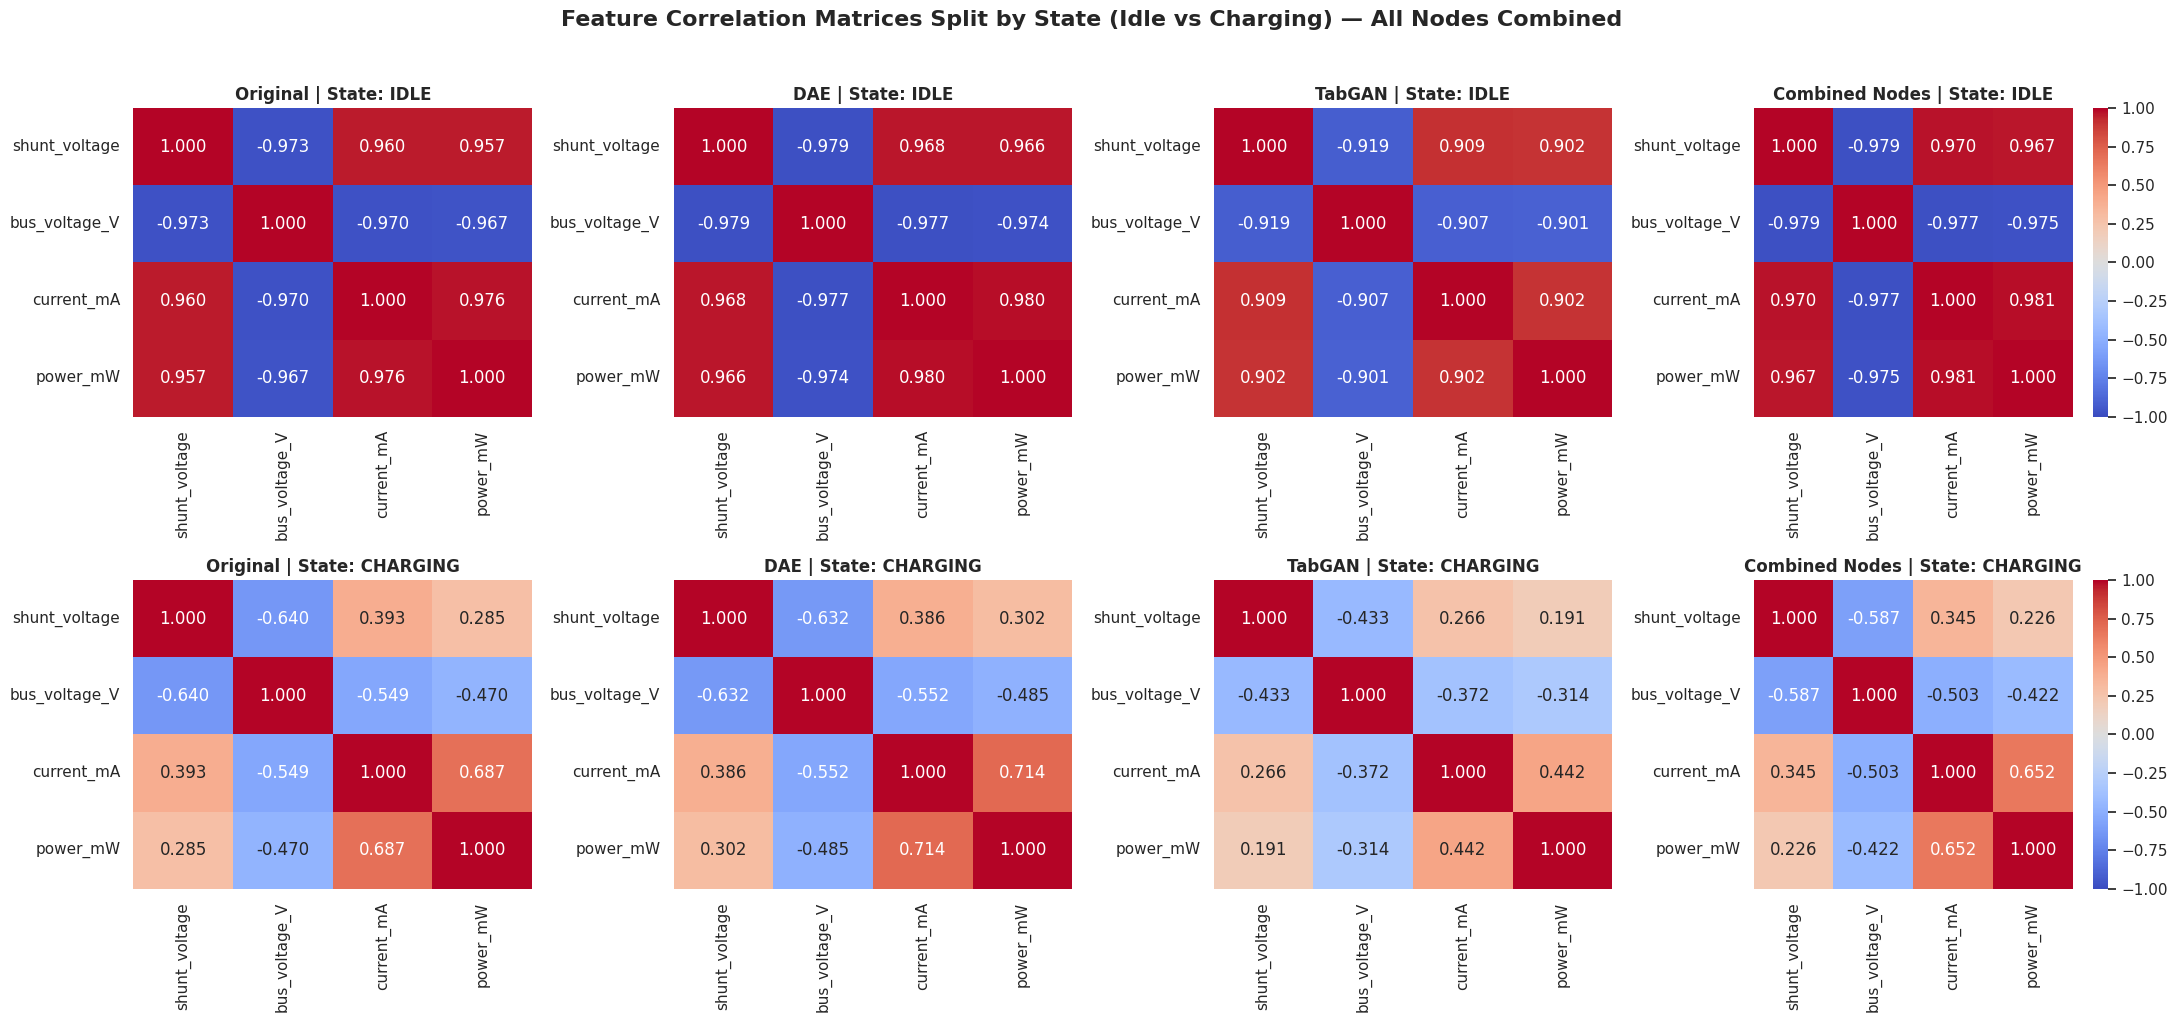

In [4]:
# Cell: Combined Multi-Node Evaluation & Correlation Analysis (Cleaned Version - Correlations Only)
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd
import seaborn as sns
from pathlib import Path

# Set visual style
sns.set_theme(style="whitegrid")

# Create plots directory if it doesn't exist
Path("plots").mkdir(parents=True, exist_ok=True)

# Base directories for normalized data
base_dir = Path("../data/dataset_synthetic extension/hyperparameter_tuning/dataset/normalized")
alt_base_dir = Path("dataset/normalized")
data_path = base_dir if base_dir.exists() else alt_base_dir

df_orig_train = pd.read_csv(data_path / "train_dataset_normalized.csv")
df_dae_train = pd.read_csv(data_path / "dae_synthetic_dataset_normalized.csv")
df_tabgan_train = pd.read_csv(data_path / "tabgan_synthetic_dataset_normalized.csv")

# Automatically find and combine all pre-normalized Node train files (Node_*_train_normalized.csv)
node_train_files = list(Path("dataset/normalized").glob("Node_*_train_normalized.csv"))
if not node_train_files:
    node_train_files = list(Path(".").glob("dataset/normalized/Node_*_train_normalized.csv"))
if not node_train_files:
    node_train_files = list(Path("dataset").glob("Node_*_train_normalized.csv"))
if not node_train_files:
    node_train_files = list(Path("../dataset/normalized").glob("Node_*_train_normalized.csv"))

print(f"Found {len(node_train_files)} pre-normalized node train datasets to combine.")

node_dfs = []
for file_path in node_train_files:
    node_df = pd.read_csv(file_path)
    
    # Ignore/skip rows where Attack is 'noneX2'
    if "Attack" in node_df.columns:
        node_df = node_df[node_df["Attack"] != "noneX2"].reset_index(drop=True)
        
    # Standardize state column values to lowercase
    if "State" in node_df.columns:
        node_df["State"] = node_df["State"].astype(str).str.lower()
        
    node_dfs.append(node_df)

if node_dfs:
    df_node_train = pd.concat(node_dfs, ignore_index=True)
else:
    raise FileNotFoundError("No node train files found matching 'Node_*_train_normalized.csv'.")

# Ensure base datasets also have consistent lowercase states
for df_target in [df_orig_train, df_dae_train, df_tabgan_train]:
    if "State" in df_target.columns:
        df_target["State"] = df_target["State"].astype(str).str.lower()

# --- Correlation Matrices Split by State (Idle vs Charging) + Plain Values for Combined Nodes ---
feature_cols_corr = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

datasets_dict = {
    "Original": df_orig_train,
    "DAE": df_dae_train,
    "TabGAN": df_tabgan_train,
    "Combined Nodes": df_node_train
}

states = ["idle", "charging"]

print("==========================================")
print(" CORRELATION MATRICES BY STATE (ALL NODES) ")
print("==========================================")

for state_val in states:
    for name, df in datasets_dict.items():
        df_filtered = df[df["State"] == state_val][feature_cols_corr]
        print(f"\n--- {name} | State: {state_val.upper()} ---")
        if not df_filtered.empty:
            print(df_filtered.corr().round(4))
        else:
            print("No data available.")
print("\n" + "=" * 42 + "\n")

fig, axes = plt.subplots(len(states), len(datasets_dict), figsize=(22, 10))

for row_idx, state_val in enumerate(states):
    for col_idx, (name, df) in enumerate(datasets_dict.items()):
        ax = axes[row_idx, col_idx]
        df_filtered = df[df["State"] == state_val][feature_cols_corr]

        if not df_filtered.empty:
            corr_matrix = df_filtered.corr()
            sns.heatmap(
                corr_matrix,
                annot=True,
                fmt=".3f",
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
                ax=ax,
                cbar=(col_idx == len(datasets_dict) - 1),
            )
        else:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")

        ax.set_title(f"{name} | State: {state_val.upper()}", fontsize=12, fontweight="bold")

plt.suptitle("Feature Correlation Matrices Split by State (Idle vs Charging) — All Nodes Combined", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
# SAVE CORRELATION PLOT
plt.savefig("plots/correlation_matrices.png", dpi=300, bbox_inches='tight')
plt.show()